In [ ]:
# Setup — runs automatically. Loads the dataset and the libraries every
# guided task expects (pandas, numpy, matplotlib, statsmodels, scikit-learn).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
df = pd.read_csv('Adidas US Sales.csv')

In [ ]:
df.head(20)

,sales_id,retailer,retailer_id,invoice_date,region,state,city,product,price_per_unit,units_sold,total_sales,operating_profit,sales_method
0,1,Foot Locker,1185732,2021-11-06,Southeast,South Carolina,Charleston,Men's Street Footwear,50,278,13900,792,Online
1,2,Foot Locker,1185732,2020-03-14,Northeast,New York,New York,Men's Apparel,46,278,12788,435,Outlet
2,3,West Gear,1128299,2021-01-19,West,California,San Francisco,Men's Athletic Footwear,47,278,13066,287,Outlet
3,4,Walmart,1128299,2021-06-17,Southeast,Florida,Orlando,Women's Apparel,103,218,22454,1257,Online
4,5,Sports Direct,1197831,2021-09-14,South,Alabama,Birmingham,Women's Street Footwear,36,278,10008,530,Outlet
5,6,West Gear,1197831,2021-07-06,West,Idaho,Boise,Women's Street Footwear,34,278,9452,397,Outlet
6,7,West Gear,1128299,2021-01-12,West,California,San Francisco,Men's Street Footwear,56,277,15512,698,Online
7,8,Foot Locker,1185732,2020-01-21,Northeast,New York,New York,Women's Street Footwear,36,276,9936,467,Online
8,9,Walmart,1197831,2020-08-17,South,Texas,Houston,Women's Apparel,37,276,10212,643,Online
9,10,West Gear,1128299,2021-07-16,South,Louisiana,New Orleans,Women's Apparel,103,163,16789,806,Online


In [ ]:
df.shape

(9637, 13)

In [ ]:
df.columns

Index(['sales_id', 'retailer', 'retailer_id', 'invoice_date', 'region',
       'state', 'city', 'product', 'price_per_unit', 'units_sold',
       'total_sales', 'operating_profit', 'sales_method'],
      dtype='object')

In [ ]:
df.dtypes

,0
sales_id,int64
retailer,object
retailer_id,int64
invoice_date,object
region,object
state,object
city,object
product,object
price_per_unit,int64
units_sold,int64


In [ ]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
print(f"Date range: {df['invoice_date'].min().date()} → {df['invoice_date'].max().date()}")

Date range: 2020-01-01 → 2021-12-31


In [ ]:
df = df.rename(columns={'invoice_date': 'Invoice date'})

In [ ]:
print(f"Date range: {df['Invoice date'].min().date()} → {df['Invoice date'].max().date()}")

Date range: 2020-01-01 → 2021-12-31


In [ ]:
print("Revenue summary:")
print(df['total_sales'].describe().map('{:,.2f}'.format))

Revenue summary:
count     9,637.00
mean     12,451.62
std      12,708.09
min         160.00
25%       4,068.00
50%       7,805.00
75%      15,834.00
max      82,500.00
Name: total_sales, dtype: object


In [ ]:
df.isnull().sum()

,0
sales_id,0
retailer,0
retailer_id,0
Invoice date,0
region,0
state,0
city,0
product,0
price_per_unit,0
units_sold,0


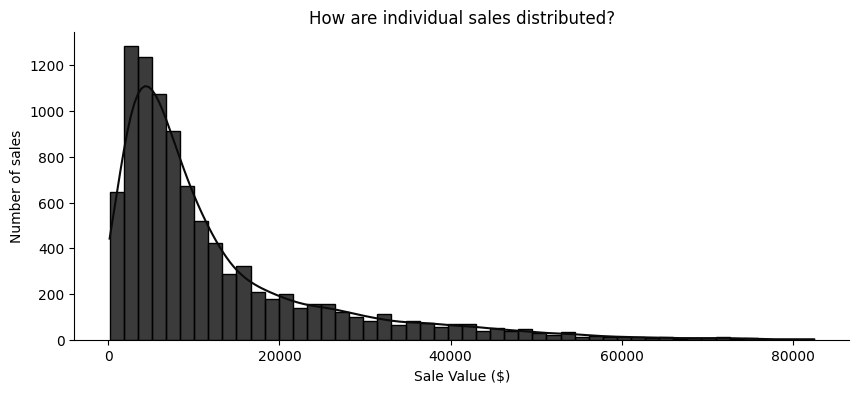

In [ ]:
# Plot a histogram to see the shape of the distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['total_sales'], bins=50, color='#0a0a0a', alpha=0.8, kde=True)
plt.title('How are individual sales distributed?')
plt.xlabel('Sale Value ($)')
plt.ylabel('Number of sales')
sns.despine()
plt.show()

In [ ]:
df['total_sales'] = pd.to_numeric(df['total_sales'], errors='coerce')

In [ ]:
print(df['units_sold'].describe())

count    9637.000000
mean      256.886064
std       214.097600
min         6.000000
25%       106.000000
50%       176.000000
75%       350.000000
max      1275.000000
Name: units_sold, dtype: float64


In [ ]:
df.groupby('product')['units_sold'].mean().sort_values(ascending=False)

,units_sold
product,
Men's Street Footwear,368.521739
Men's Athletic Footwear,270.180970
Women's Apparel,269.525202
Women's Street Footwear,243.738481
Women's Athletic Footwear,198.086196
Men's Apparel,190.737072


In [ ]:
# Create a 'Month' column so we can group by month
df['month'] = df['Invoice date'].dt.to_period('M')

In [ ]:
monthly_sales = df.groupby("month")['total_sales'].sum()

In [ ]:
monthly_sales

,total_sales
month,
2020-01,2312746
2020-02,2140813
2020-03,2474202
2020-04,3193081
2020-05,2164764
2020-06,1084194
2020-07,2158763
2020-08,2606630
2020-09,2367686


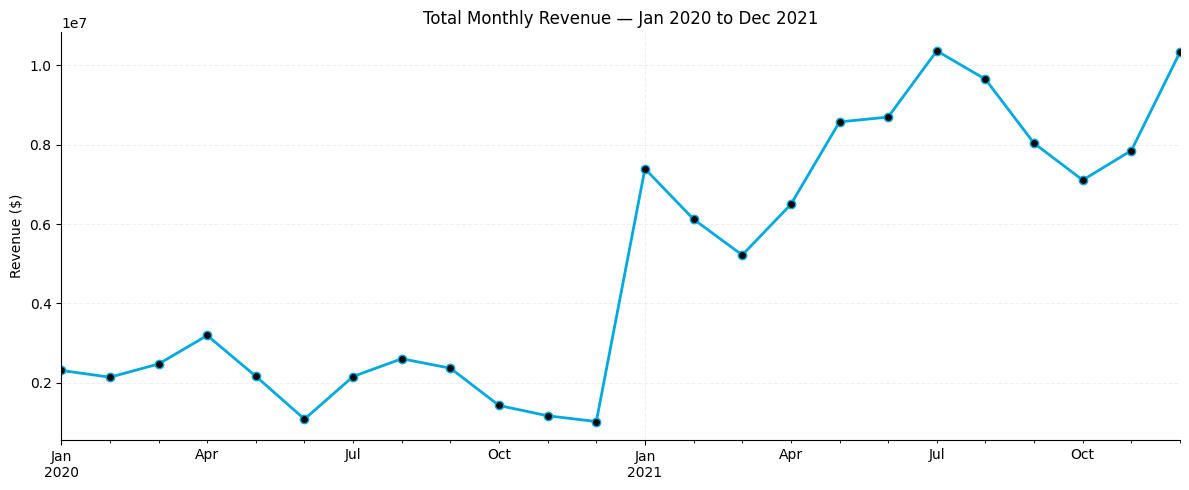

In [ ]:
# Plot the monthly totals as a line chart
plt.figure(figsize=(12, 5))
monthly_sales.plot(
    kind='line',
    marker='o',          # small dots at each data point
    color='#00A9E0',     # Adidas blue
    linewidth=2,
    markerfacecolor='#0a0a0a'
)
plt.title('Total Monthly Revenue — Jan 2020 to Dec 2021')
plt.ylabel('Revenue ($)')
plt.xlabel('')
plt.grid(alpha=0.2, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

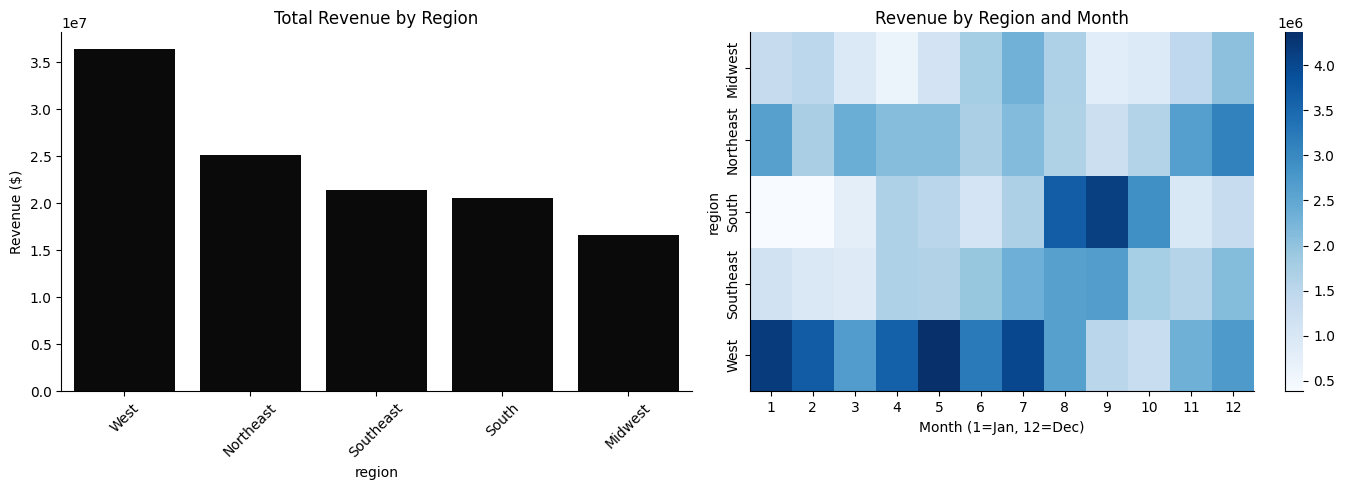

In [ ]:
# Sum total revenue by region
region_sales = df.groupby('region')['total_sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left chart: bar chart showing total revenue per region
sns.barplot(x=region_sales.index, y=region_sales.values, ax=axes[0], color='#0a0a0a')
axes[0].set_title('Total Revenue by Region')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Right chart: heatmap showing revenue by region × month
# Each cell is the total sales for that region in that month
pivot = df.pivot_table(
    values='total_sales',
    index='region',
    columns=df['Invoice date'].dt.month,
    aggfunc='sum'
)
sns.heatmap(pivot, cmap='Blues', annot=False, ax=axes[1])
axes[1].set_title('Revenue by Region and Month')
axes[1].set_xlabel('Month (1=Jan, 12=Dec)')

sns.despine()
plt.tight_layout()
plt.show()



In [ ]:
df['total_sales'] = pd.to_numeric(df['total_sales'], errors='coerce')
df['operating_profit'] = pd.to_numeric(df['operating_profit'], errors='coerce')
df['units_sold'] = pd.to_numeric(df['units_sold'], errors='coerce')
df['price_per_unit'] = pd.to_numeric(df['price_per_unit'], errors='coerce')

In [ ]:
df['operating_margin'] = (df['operating_profit'] / df['total_sales']) * 100

print(df.groupby('product')['operating_margin'].mean()
      .sort_values(ascending=False)
      .round(1))

product
Men's Street Footwear        18.5
Women's Apparel              18.4
Women's Athletic Footwear    17.3
Men's Apparel                16.9
Women's Street Footwear      16.7
Men's Athletic Footwear      16.4
Name: operating_margin, dtype: float64


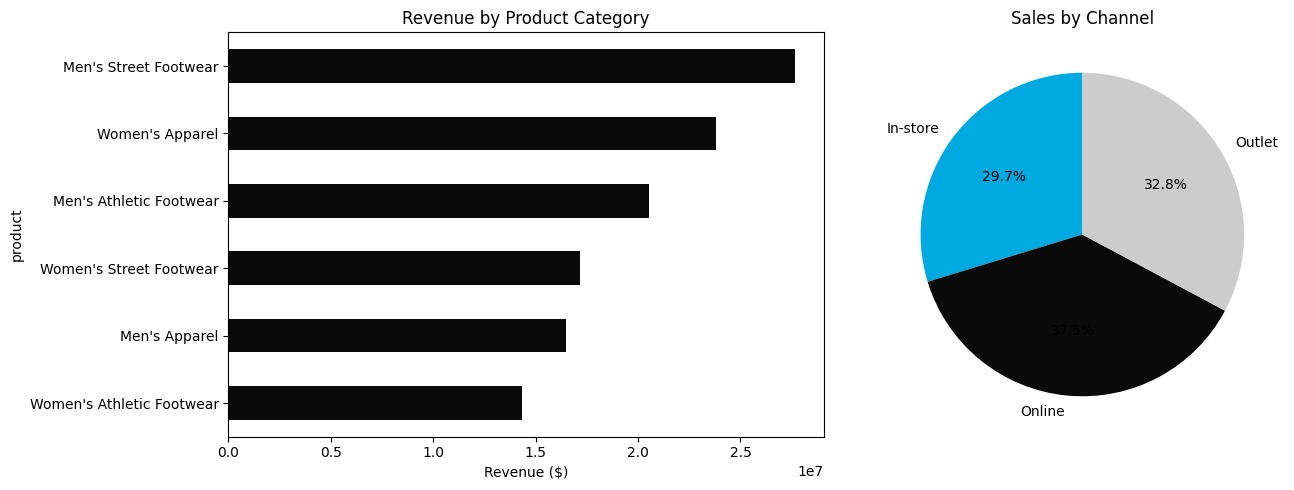

Average profit margin by product:
product
Men's Street Footwear        18.5%
Women's Apparel              18.4%
Women's Athletic Footwear    17.3%
Men's Apparel                16.9%
Women's Street Footwear      16.7%
Men's Athletic Footwear      16.4%
Name: operating_margin, dtype: object


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: horizontal bar chart of revenue by product
product_sales = df.groupby('product')['total_sales'].sum().sort_values()
product_sales.plot(kind='barh', ax=axes[0], color='#0a0a0a')
axes[0].set_title('Revenue by Product Category')
axes[0].set_xlabel('Revenue ($)')

# Right chart: pie chart showing channel mix
method_sales = df.groupby('sales_method')['total_sales'].sum()
axes[1].pie(
    method_sales,
    labels=method_sales.index,
    autopct='%1.1f%%',          # show percentages
    colors=['#00A9E0', '#0a0a0a', '#cccccc'],
    startangle=90
)
axes[1].set_title('Sales by Channel')

plt.tight_layout()
plt.show()

# Bonus: average operating margin by product
print("Average profit margin by product:")
print(df.groupby('product')['operating_margin'].mean()
      .sort_values(ascending=False)
      .map('{:.1f}%'.format))

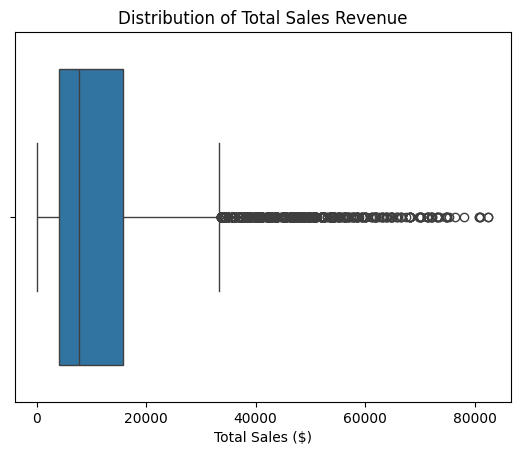

In [ ]:
# box plot for the sales revenue
sns.boxplot(x='total_sales', data=df)
plt.title('Distribution of Total Sales Revenue')
plt.xlabel('Total Sales ($)')
plt.show()

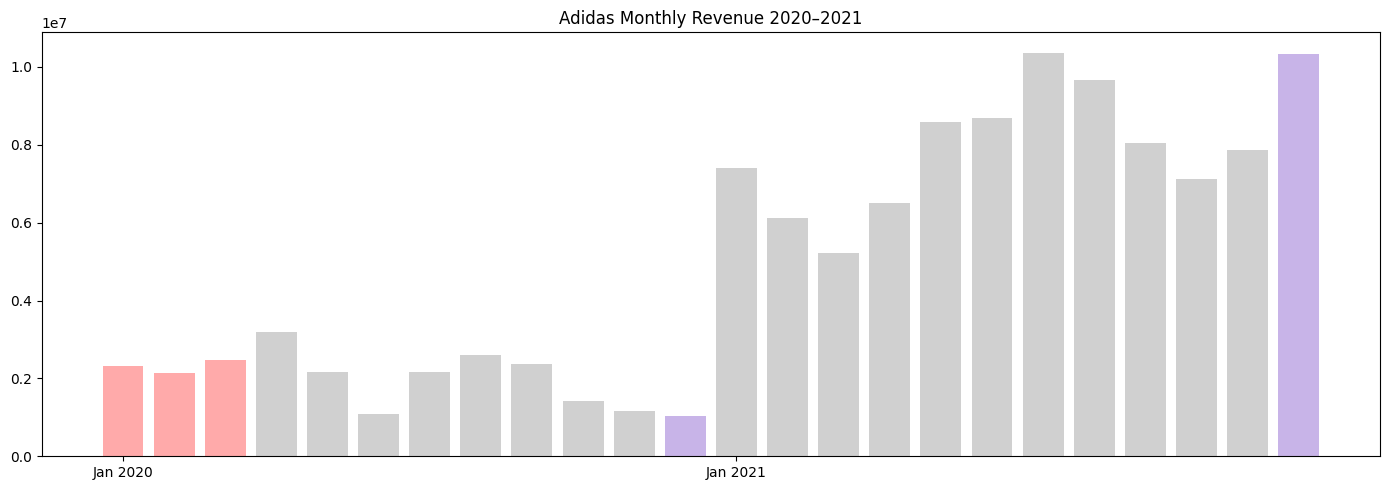

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

monthly = df.groupby('month')['total_sales'].sum().reset_index()
months = range(len(monthly))
values = monthly['total_sales'].values

colors = ['#ffaaaa' if i < 3 else '#c8b4e8' if monthly['month'].iloc[i].month == 12 else '#d0d0d0' for i in months]

plt.figure(figsize=(14, 5))
plt.bar(months, values, color=colors)
plt.xticks([0, 12], ['Jan 2020', 'Jan 2021'])
plt.title('Adidas Monthly Revenue 2020–2021')
plt.tight_layout()
plt.show()

In [ ]:
# Set the Invoice Date as the index so pandas knows this is time-series data
ts = df.set_index('Invoice date')['total_sales'].resample('M').sum()
# 'M' = monthly — pandas sums all sales that fall within each month

/tmp/ipykernel_2261/3119484159.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.set_index('Invoice date')['total_sales'].resample('M').sum()


In [ ]:
print(f"Months in dataset: {len(ts)}")
print(ts.head())  # show the first few months

Months in dataset: 24
Invoice date
2020-01-31    2312746
2020-02-29    2140813
2020-03-31    2474202
2020-04-30    3193081
2020-05-31    2164764
Freq: ME, Name: total_sales, dtype: int64
